In [1]:
# https://ngs101.com/how-to-analyze-single-cell-rna-seq-data-complete-beginners-guide-part-7-2-trajectory-analysis-using-slingshot/
# this tutorial is nice

# there's an extense review on trajectory inference methods https://www.nature.com/articles/s41587-019-0071-9
# based on this tutorials, we identified monocle3, paga and slignshot to be used.

# tutorial pymonocle: https://github.com/bioturing-org/py-monocle/blob/main/examples/monocle3_py.ipynb

# try to install pymonocle https://github.com/bioturing-org/py-monocle
# try to install pyslignshot https://github.com/mossjacob/pyslingshot/blob/master/slingshot.ipynb

# and comment all the things based on these methods.

#import pymonocle as py

In [8]:
import decoupler as dc
# import packages
import warnings
warnings.filterwarnings("ignore")

import decoupler as dc 
import pandas as pd
import scanpy as sc
import numpy as np
from pyslingshot import Slingshot
import matplotlib.pyplot as plt
import celltypist
from celltypist import models

In [2]:
# try to see if this installation work!
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)

In [3]:
DATA_DIR = "data/GSE123813"

metadata = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_metadata.txt.gz", sep="\t")
counts = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_scRNA_counts.txt.gz", sep="\t", index_col=0)

# create adata object
adata = sc.AnnData(counts.T)
adata.obs = metadata.set_index(metadata.columns[0]).loc[adata.obs_names]

In [4]:
# we need to subset for just one cell type CD4 or CD8
CD4 = ['Naive', 'Tfh', 'Th17', 'Treg']

adata = adata[adata.obs['cluster'].isin(CD4)]

# subset adata for cleaner easy analysis
np.random.seed(42)  # reproducibility


cells = np.random.choice(adata.obs_names, size=3000, replace=False)
adata_sub = adata[cells].copy()

adata = adata_sub.copy()

In [5]:
adata.obs['celltype'] = adata.obs['cluster']

In [ ]:
# It is very important the filtering for a single cell data 
# See: https://pmc.ncbi.nlm.nih.gov/articles/PMC6582955/  for more information

In [6]:
# Classical scanpy
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata,n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
#sc.tl.paga(adata, groups="celltype")   # now yes.

sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2) # in this case is reproducible.


In [11]:
## celltype identification using celltypist
models.download_models(
    model = [
        "Immune_All_Low.pkl",
        "Immune_All_High.pkl"
    ],
    force_update=True
)



2026-03-03 13:29:24 | [INFO] 📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
2026-03-03 13:29:24 | [INFO] 📚 Total models in list: 60
2026-03-03 13:29:24 | [INFO] 📂 Storing models in /home/roger/.celltypist/data/models
2026-03-03 13:29:24 | [INFO] 💾 Total models to download: 2
2026-03-03 13:29:24 | [INFO] 💾 Downloading model [1/2]: Immune_All_Low.pkl
2026-03-03 13:29:25 | [INFO] 💾 Downloading model [2/2]: Immune_All_High.pkl
2026-03-03 13:29:25 | [INFO] 🔬 Input data has 3000 cells and 18347 genes
2026-03-03 13:29:25 | [INFO] 🔗 Matching reference genes in the model
2026-03-03 13:29:26 | [INFO] 🧬 5077 features used for prediction
2026-03-03 13:29:26 | [INFO] ⚖️ Scaling input data
2026-03-03 13:29:27 | [INFO] 🖋️ Predicting labels
2026-03-03 13:29:27 | [INFO] ✅ Prediction done!
2026-03-03 13:29:27 | [INFO] 👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
2026-03-03 13:29:27 | [INFO] ⛓️ Over-clustering

In [18]:
# we already know that these cells are from the immune system as they are sorted
# we can use Immune All Low , or High (depending on the resolution) see celltypist for more information
# we do majority voting, as we want each cell type to be associated with a leiden cluster
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)
#predictions_high = celltypist.annotate(adata, model = 'Immune_All_High.pkl', majority_voting = True)

adata = predictions.to_adata()
#adata = predictions_high.to_adata()

2026-03-03 13:31:33 | [INFO] 🔬 Input data has 3000 cells and 18347 genes
2026-03-03 13:31:33 | [INFO] 🔗 Matching reference genes in the model
2026-03-03 13:31:34 | [INFO] 🧬 5077 features used for prediction
2026-03-03 13:31:34 | [INFO] ⚖️ Scaling input data
2026-03-03 13:31:35 | [INFO] 🖋️ Predicting labels
2026-03-03 13:31:35 | [INFO] ✅ Prediction done!
2026-03-03 13:31:35 | [INFO] 👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
2026-03-03 13:31:35 | [INFO] ⛓️ Over-clustering input data with resolution set to 5
2026-03-03 13:31:35 | [INFO] 🗳️ Majority voting the predictions
2026-03-03 13:31:35 | [INFO] ✅ Majority voting done!
2026-03-03 13:31:35 | [INFO] 🔬 Input data has 3000 cells and 18347 genes
2026-03-03 13:31:35 | [INFO] 🔗 Matching reference genes in the model
2026-03-03 13:31:36 | [INFO] 🧬 5077 features used for prediction
2026-03-03 13:31:36 | [INFO] ⚖️ Scaling input data
2026-03-03 13:31:36 | [INFO] 🖋️ Predicting labels
2026-03-0

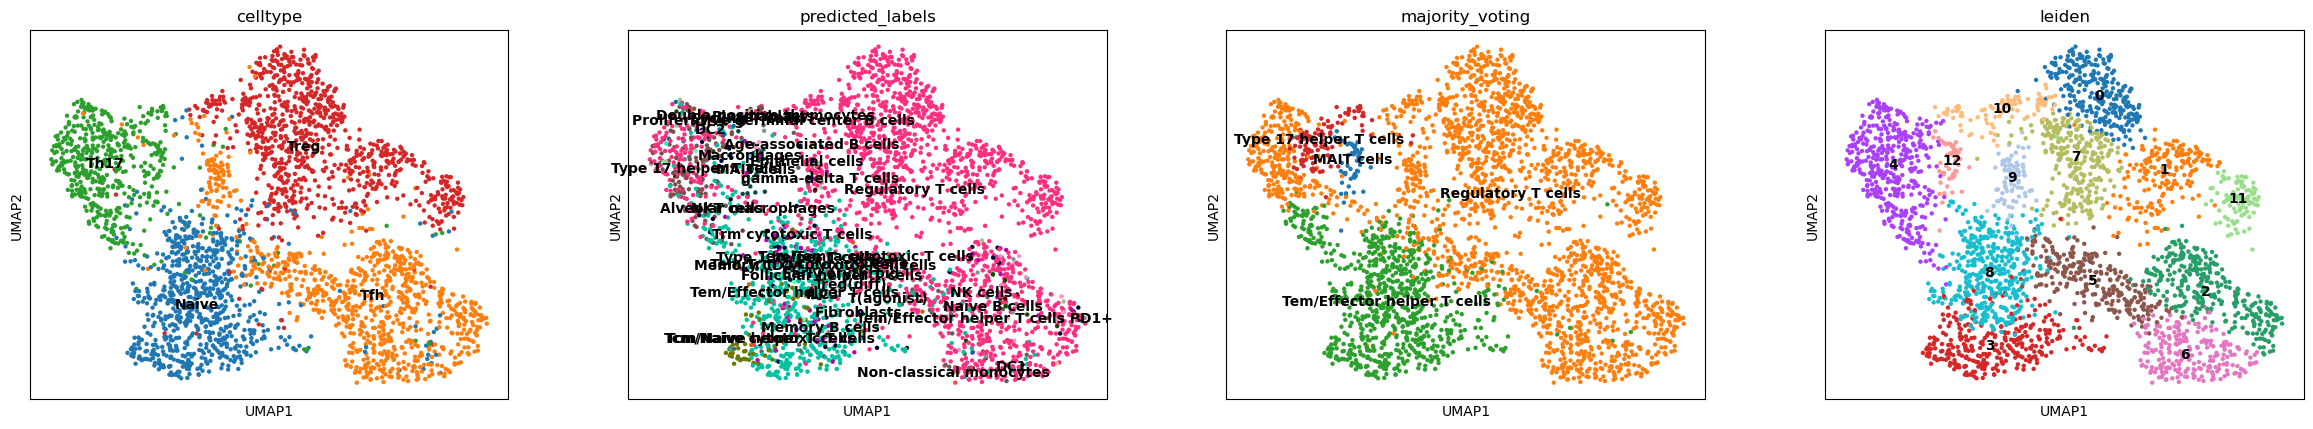

In [25]:
# first problem, we do have several different annotations in here, 
#first step, define which is our best annotation, what do we believe. We can inspect marker genes for the annotation
# this is a critical step for further understanding the biology under the trajectories.
sc.pl.umap(adata, color = ['celltype', 'predicted_labels', 'majority_voting', 'leiden'], legend_loc = 'on data')

In [28]:
sc.tl.rank_genes_groups(adata, groupby="celltype", reference="rest")

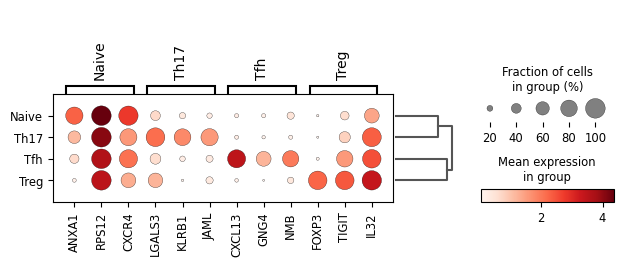

In [29]:
sc.pl.rank_genes_groups_dotplot(adata,  n_genes=3)

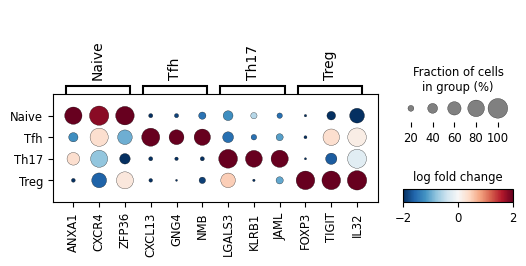

In [30]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=3,
    min_logfoldchange=1,
    values_to_plot="logfoldchanges",
    cmap="RdBu_r",    
    vmin=-2,          
    vmax=2,           
    dendrogram=False,
    show=True
)

In [ ]:
#we continue with the autors annotation, but remember that this is very important!!

In [ ]:
# another key issue in here, is that most methods do graph embeedding, this means that changing the 
# umap parameters they will change the results.... 

In [ ]:
#this is also a key issue here, defining the root node, in this case we know that is naive, 
# this is based on literature deriving, on lymphocytes in immunotherapy, normally we do have naive,
# or even memory, the step before of the differentiation trajectory, this can be revisable with a immuno

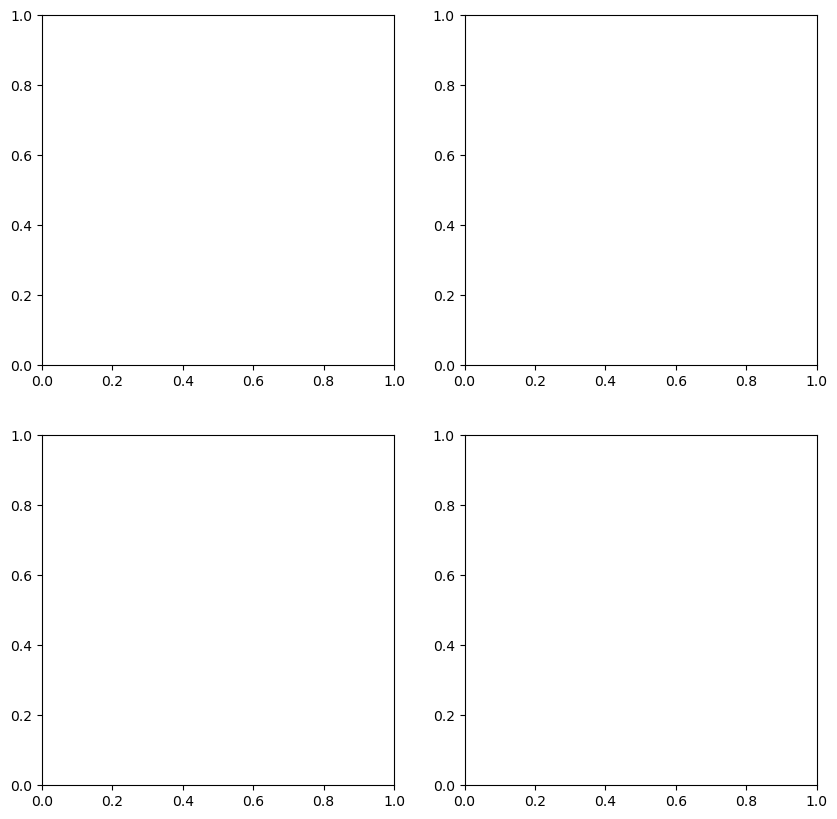

In [39]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10));
custom_xlim = (-12, 12);
custom_ylim = (-12, 12);

In [40]:
### Slingshot
slingshot = Slingshot(adata, celltype_key="celltype", obsm_key="X_umap", start_node=0, is_debugging="verbose")

slingshot.fit(num_epochs=1, debug_axes=axes)  # we can change the number of epochs for better training

Lineages: [Lineage[0, np.int64(1), np.int64(3)], Lineage[0, np.int64(2)]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @0 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x78c1400e82b0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x78c1400ea650>]
Shrinking branch @0 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x78c1400e82b0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x78c1400ea650>]


<Figure size 640x480 with 0 Axes>

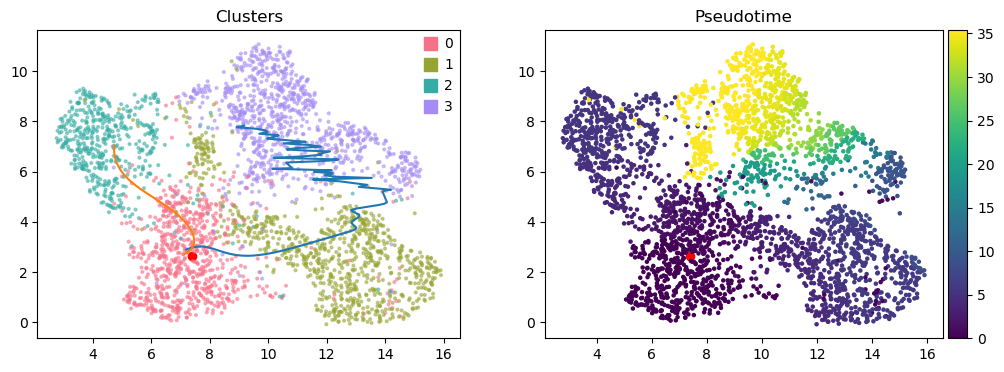

In [41]:

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
axes[0].set_title("Clusters")
axes[1].set_title("Pseudotime")
slingshot.plotter.curves(axes[0], slingshot.curves)
slingshot.plotter.clusters(axes[0], labels=np.arange(slingshot.num_clusters), s=4, alpha=0.5)
slingshot.plotter.clusters(axes[1], color_mode="pseudotime", s=5)

In [42]:
### MONOCLE

projected_points, mst, centroids = learn_graph(matrix=adata.obsm['X_umap'], clusters=adata.obs['celltype'])

In [44]:
pseudotime = order_cells(
    adata.obsm['X_umap'], centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=0,
)

In [45]:
umap = adata.obsm['X_umap']
louvain = adata.obs['celltype']

In [47]:
# we should define a palette for our analysis.
palette = {
    "Naive":  "#4C72B0",   # blue
    "Tfh":    "#DD8452",   # orange
    "Th17":   "#55A868",   # green
    "Treg":   "#C44E52",   # red
}

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not {'Naive': '#4C72B0', 'Tfh': '#DD8452', 'Th17': '#55A868', 'Treg': '#C44E52'}

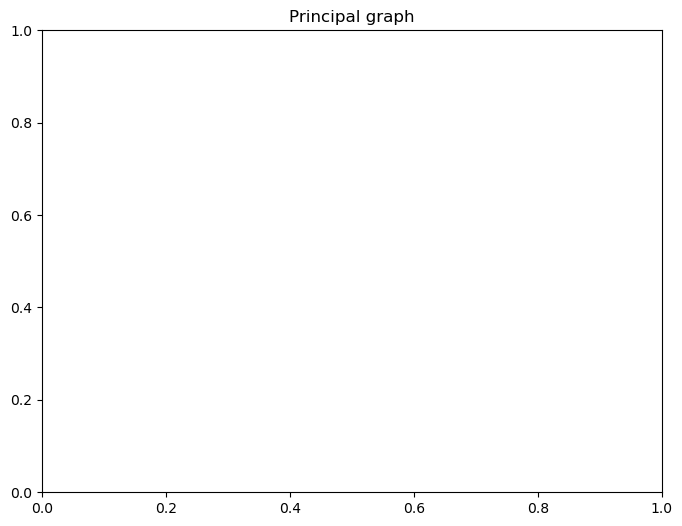

In [48]:
plt.figure(1, (8, 6))
plt.title("Principal graph")
plt.scatter(umap[:, 0], umap[:, 1], c=palette, s=1, cmap="nipy_spectral") 

# i need to change and put a palette for the celltypes.

edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
### PAGA
